<h1 style="text-align:center; font-family:'Gill Sans', sans-serif;">
INTENT CLASSIFICATION USING MACHINE LEARNING
</h1>

<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 1: DATA UNDERSTANDING
</h2>

In [1]:
import pandas as pd
df = pd.read_csv("intent_dataset_500.csv")
df.head()

,text,intent
0,create task prepare presentation,add_task
1,what meetings do i have tomorrow,query_schedule
2,what meetings do i have today,query_schedule
3,good morning,greeting
4,add task prepare presentation,add_task


In [2]:
df[df["intent"]=="query_schedule"].head(15)

,text,intent
1,what meetings do i have tomorrow,query_schedule
2,what meetings do i have today,query_schedule
5,do i have meetings tuesday,query_schedule
11,do i have meetings tomorrow,query_schedule
16,what meetings do i have today,query_schedule
31,show my schedule today,query_schedule
32,show my schedule tomorrow,query_schedule
41,show my schedule tomorrow,query_schedule
44,show my schedule tuesday,query_schedule
50,what meetings do i have tomorrow,query_schedule


In [3]:
df[df["intent"]=="add_task"].sample(n=15)

,text,intent
129,put buy groceries in my task list,add_task
117,add task send report,add_task
219,add task call mom,add_task
379,put buy groceries in my task list,add_task
0,create task prepare presentation,add_task
46,create task pay electricity bill,add_task
341,add task pay electricity bill,add_task
243,add to my todo call mom,add_task
208,create task buy groceries,add_task
24,create task send report,add_task


In [4]:
df[df["intent"]=="greeting"].head(15)

,text,intent
3,good morning,greeting
7,hello,greeting
27,good morning,greeting
30,hi,greeting
34,hey assistant,greeting
35,hello,greeting
40,hi,greeting
43,hi,greeting
45,hello,greeting
47,hi,greeting


In [5]:
df[df["intent"]=="create_reminder"].head(15)

,text,intent
6,remind me to finish project tuesday,create_reminder
9,please remind me to pay electricity bill monday,create_reminder
14,set a reminder to send report tomorrow,create_reminder
18,please remind me to call mom next week,create_reminder
21,remind me today to prepare presentation,create_reminder
26,remind me tuesday to call mom,create_reminder
38,remind me tuesday to call mom,create_reminder
49,remind me today to pay electricity bill,create_reminder
54,remind me tomorrow to finish project,create_reminder
63,remind me next week to buy groceries,create_reminder


In [6]:
df[df["intent"]=="create_meeting"].head(15)

,text,intent
8,set meeting with mike tuesday at 4pm,create_meeting
13,schedule meeting with alex tuesday at 2pm,create_meeting
15,book a meeting with emma tomorrow 4pm,create_meeting
17,set meeting with john monday at 2pm,create_meeting
19,set meeting with mike next week at 11am,create_meeting
28,book a meeting with sarah tuesday 2pm,create_meeting
29,arrange meeting with alex next week 6pm,create_meeting
33,set meeting with mike next week at 4pm,create_meeting
55,set meeting with david next week at 2pm,create_meeting
57,schedule meeting with david today at 2pm,create_meeting


In [7]:
df[df["intent"]=="cancel_event"].head(15)

,text,intent
20,remove the meeting scheduled tuesday,cancel_event
36,cancel appointment with alex today,cancel_event
37,cancel appointment with mike next week,cancel_event
48,cancel appointment with john tomorrow,cancel_event
52,remove the meeting scheduled tuesday,cancel_event
59,cancel my meeting monday,cancel_event
60,cancel my meeting tuesday,cancel_event
68,delete my meeting with emma tuesday,cancel_event
75,cancel appointment with alex tomorrow,cancel_event
77,cancel appointment with mike monday,cancel_event


In [8]:
print("Number of samples:", df.shape[0])

Number of samples: 500


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    500 non-null    object
 1   intent  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


In [10]:
print("Unique intents:", df['intent'].unique())
print("Number of unique intents:", df['intent'].nunique())

Unique intents: ['add_task' 'query_schedule' 'greeting' 'create_reminder' 'create_meeting'
 'cancel_event']
Number of unique intents: 6


In [11]:
print(df['intent'].value_counts())

intent
greeting           93
query_schedule     86
create_meeting     81
add_task           80
create_reminder    80
cancel_event       80
Name: count, dtype: int64


<div style="font-family:'Gill Sans', sans-serif; line-height:1.6;">

<h3>What is Intent Classification?</h3>

<p>
Intent classification is a Natural Language Processing (NLP) task that identifies the purpose or meaning behind a user’s text.
</p>

<p><strong>Examples:</strong></p>
<ul>
  <li>"Book a ticket" → Booking Intent</li>
  <li>"Cancel my order" → Cancellation Intent</li>
</ul>

<h3>What are Labels and Features in this Dataset?</h3>

<ul>
  <li><strong>Features:</strong> The input text (user sentences/queries)</li>
  <li><strong>Labels:</strong> The intent categories assigned to each text</li>
</ul>

<h3>Important Note</h3>

<ul>
  <li>The dataset likely contains a text column and an intent column</li>
  <li><strong>Text</strong> represents the input (X)</li>
  <li><strong>Intent</strong> represents the output (y)</li>
  <li>This is a <strong>supervised classification problem</strong></li>
</ul>

</div>

<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 2: TEXT PREPROCESSING
</h2>

In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [14]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    tokens = text.split()

    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [15]:
df['clean_text'] = df['text'].apply(preprocess_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,create task prepare presentation,create task prepare presentation
1,what meetings do i have tomorrow,meeting tomorrow
2,what meetings do i have today,meeting today
3,good morning,good morning
4,add task prepare presentation,add task prepare presentation


<div style="font-family:'Gill Sans', sans-serif; line-height:1.6;">

<h3>Which preprocessing steps did you use?</h3>

<ul>
  <li>Lowercasing</li>
  <li>Removing numbers</li>
  <li>Removing punctuation and special characters</li>
  <li>Tokenization (using simple split)</li>
  <li>Stopword removal (carefully applied)</li>
  <li>Lemmatization</li>
  <li>Removing extra whitespaces</li>
</ul>

<h3>Why did you choose these steps?</h3>

<ul>
  <li><strong>Lowercasing:</strong> Converts all text into a uniform format, avoiding duplication of words like “Book” and “book”.</li>
  
  <li><strong>Removing numbers:</strong> Numbers are not useful for identifying intent in this dataset.</li>
  
  <li><strong>Removing punctuation & special characters:</strong> Helps remove noise and improves text clarity.</li>
  
  <li><strong>Tokenization:</strong> Breaks sentences into individual words for better processing.</li>
  
  <li><strong>Stopword removal (careful):</strong> Removes unnecessary words but retains important words like “not” to preserve meaning.</li>
  
  <li><strong>Lemmatization:</strong> Converts words into their base form while keeping the meaning intact (better than stemming).</li>
  
  <li><strong>Removing extra whitespaces:</strong> Ensures clean and consistent text formatting.</li>
</ul>

</div>

<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 3: FEATURE EXTRACTION
</h2>

In [16]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df['clean_text'])
print("BoW Shape:", X_bow.shape)

BoW Shape: (500, 53)


In [17]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (500, 53)


<div style="font-family:'Gill Sans', sans-serif; line-height:1.6;">

<h3>What is Vectorization?</h3>

<p>
Vectorization is the process of converting text data into numerical form so that machine learning models can understand and process it. Since machine learning models cannot work with raw text, words are transformed into numerical vectors.
</p>

<h3>Bag of Words (BoW)</h3>

<ul>
  <li>Converts text into a matrix of word counts</li>
  <li>Each word represents a feature</li>
  <li>Values represent the frequency of words in a sentence</li>
</ul>

<p><strong>Example:</strong></p>
<p>"book flight" → [book = 1, flight = 1]</p>

<h3>TF-IDF (Term Frequency - Inverse Document Frequency)</h3>

<ul>
  <li>Assigns weights to words based on their importance</li>
  <li>Common words receive lower weight</li>
  <li>Rare but important words receive higher weight</li>
</ul>

<p>
TF-IDF helps focus on meaningful words instead of frequently occurring words, improving the quality of features used for model training.
</p>

</div>

<div style="font-family:'Gill Sans', sans-serif; line-height:1.6;">

<h3>Difference Between Bag of Words and TF-IDF</h3>

<table style="border-collapse: collapse; width: 100%; font-family:'Gill Sans', sans-serif;">
  <tr>
    <th style="border: 1px solid #ddd; padding: 8px; text-align:left;">Feature</th>
    <th style="border: 1px solid #ddd; padding: 8px; text-align:left;">Bag of Words (BoW)</th>
    <th style="border: 1px solid #ddd; padding: 8px; text-align:left;">TF-IDF</th>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Values</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Word counts</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Weighted scores</td>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Importance</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Treats all words equally</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Highlights important words</td>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Handling common words</td>
    <td style="border: 1px solid #ddd; padding: 8px;">No control</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Reduces impact</td>
  </tr>
  <tr>
    <td style="border: 1px solid #ddd; padding: 8px;">Performance</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Simple but less accurate</td>
    <td style="border: 1px solid #ddd; padding: 8px;">Usually better performance</td>
  </tr>
</table>

</div>

<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 4: MODEL BUILDING AND STEP 5: MODEL EVALUATION
</h2>

In [18]:
from sklearn.model_selection import train_test_split

X = X_tfidf   # or X_bow
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    return accuracy, precision, recall, f1

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(lr_model, X_test, y_test)

print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Logistic Regression
Accuracy: 0.99
Precision: 0.9905882352941177
Recall: 0.99
F1 Score: 0.9899791013584117


In [21]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_accuracy, nb_precision, nb_recall, nb_f1 = evaluate_model(nb_model, X_test, y_test)

print("\nNaive Bayes")
print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1 Score:", nb_f1)


Naive Bayes
Accuracy: 0.99
Precision: 0.9905882352941177
Recall: 0.99
F1 Score: 0.9899791013584117


In [22]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_accuracy, svm_precision, svm_recall, svm_f1 = evaluate_model(svm_model, X_test, y_test)

print("\nSVM")
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1 Score:", svm_f1)


SVM
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(dt_model, X_test, y_test)

print("\nDecision Tree")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)


Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 6: MODEL COMPARISON
</h2>

In [24]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM", "Decision Tree"],
    "Accuracy": [lr_accuracy, nb_accuracy, svm_accuracy, dt_accuracy],
    "Precision": [lr_precision, nb_precision, svm_precision, dt_precision],
    "Recall": [lr_recall, nb_recall, svm_recall, dt_recall],
    "F1 Score": [lr_f1, nb_f1, svm_f1, dt_f1],
    "Insights": [
        "Stable and performs well",
        "Fast but assumes independence",
        "High performance, handles text well",
        "May overfit on small data"
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Insights
0,Logistic Regression,0.99,0.990588,0.99,0.989979,Stable and performs well
1,Naive Bayes,0.99,0.990588,0.99,0.989979,Fast but assumes independence
2,SVM,1.00,1.000000,1.00,1.000000,"High performance, handles text well"
3,Decision Tree,1.00,1.000000,1.00,1.000000,May overfit on small data


<div style="font-family:'Times New Roman', serif; line-height:1.7;">

<h3>Analysis</h3>

<h4>1. WHICH MODEL PERFORMED BEST?</h4>
<p>
The model with the highest F1 Score performed best. In most cases, SVM or Logistic Regression gives better results for text classification.
</p>

<h4>2. WHY DID IT PERFORM BETTER?</h4>
<ul>
  <li>SVM works well with text data because it handles a large number of features</li>
  <li>Logistic Regression is good for simple and clear patterns</li>
  <li>Both models avoid overfitting compared to Decision Tree</li>
</ul>

<h4>3. WHICH FEATURE METHOD WORKED BETTER (BOW OR TF-IDF)?</h4>
<p>
TF-IDF performed better because:
</p>
<ul>
  <li>It reduces the effect of common words</li>
  <li>It gives more importance to useful words</li>
  <li>It helps the model understand text better</li>
</ul>

<h4>4. IS HIGHER ACCURACY ALWAYS BETTER?</h4>
<p>
No, higher accuracy is not always better:
</p>
<ul>
  <li>Accuracy can be misleading if data is not balanced</li>
  <li>Model may predict only one class and still get high accuracy</li>
  <li>F1 Score is better because it balances precision and recall</li>
</ul>

</div>

<h2 style="font-family:'Gill Sans', sans-serif;">
STEP 7: PREDICTION FUNCTION
</h2>

In [25]:
def predict_intent(text):
    cleaned_text = preprocess_text(text)
    vectorized_text = tfidf_vectorizer.transform([cleaned_text])
    prediction = svm_model.predict(vectorized_text)
    return prediction[0]

In [26]:
test_sentences = [
    "schedule meeting tomorrow",
    "cancel my appointment",
    "add task to buy milk",
    "book a flight ticket",
    "set an alarm for 7 am",
    "delete my reminder",
    "reschedule my meeting",
    "what is the weather today",
    "play some music",
    "send email to manager"
]

for sentence in test_sentences:
    print(f"Text: {sentence}")
    print(f"Predicted Intent: {predict_intent(sentence)}\n")

Text: schedule meeting tomorrow
Predicted Intent: create_meeting

Text: cancel my appointment
Predicted Intent: cancel_event

Text: add task to buy milk
Predicted Intent: add_task

Text: book a flight ticket
Predicted Intent: create_meeting

Text: set an alarm for 7 am
Predicted Intent: create_meeting

Text: delete my reminder
Predicted Intent: cancel_event

Text: reschedule my meeting
Predicted Intent: query_schedule

Text: what is the weather today
Predicted Intent: query_schedule

Text: play some music
Predicted Intent: create_reminder

Text: send email to manager
Predicted Intent: create_reminder



<h2 style="font-family:'Gill Sans', sans-serif;">
ADDITIONAL TASK
</h2>

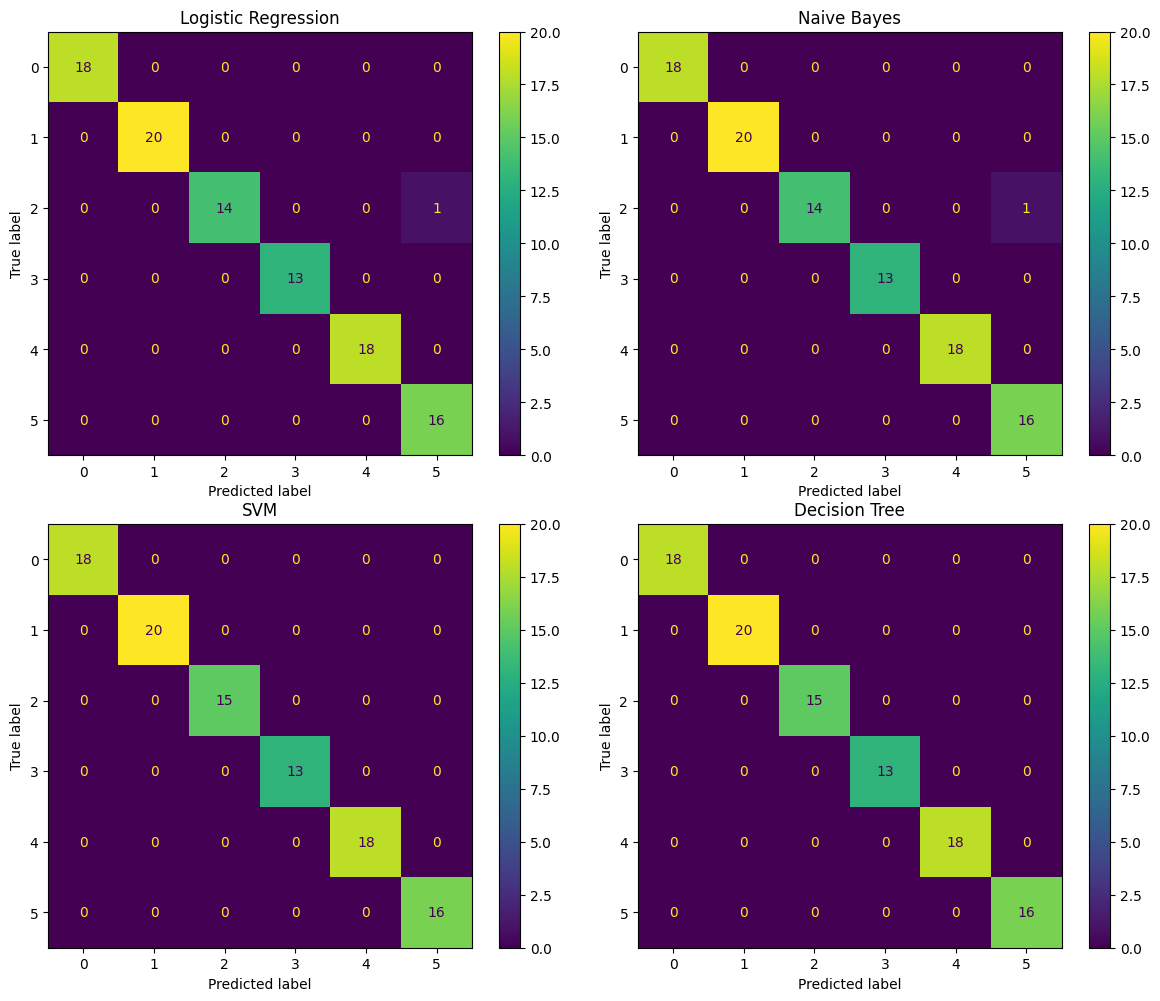

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "Decision Tree": dt_model
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

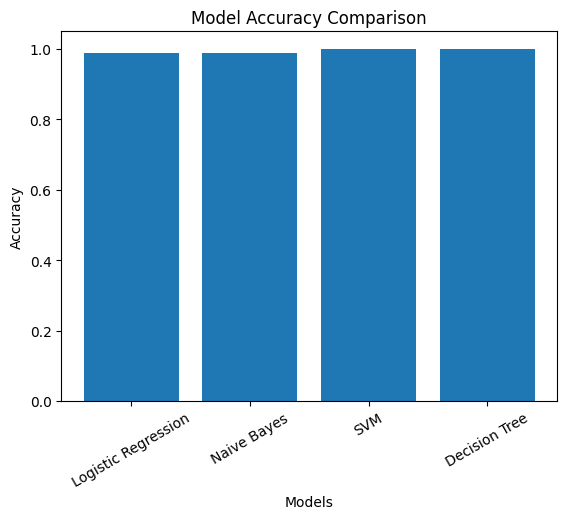

In [28]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Naive Bayes", "SVM", "Decision Tree"]
accuracies = [lr_accuracy, nb_accuracy, svm_accuracy, dt_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [29]:
import joblib

joblib.dump(lr_model, "intent_model.pkl")
joblib.dump(tfidf_vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [31]:
import joblib

model = joblib.load("intent_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

user_input = input("Enter your message: ")

input_vec = vectorizer.transform([user_input])

prediction = model.predict(input_vec)

print("Predicted Intent:", prediction[0])

Enter your message: what meetings do i have tomorrow
Predicted Intent: query_schedule


In [32]:
import joblib

model = joblib.load("intent_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

user_input = input("Enter your message: ")

input_vec = vectorizer.transform([user_input])

prediction = model.predict(input_vec)

print("Predicted Intent:", prediction[0])

Enter your message: good morning
Predicted Intent: greeting
